In [37]:
# Install necessary library
!pip install opendatasets --upgrade --quiet

import opendatasets as od
import pandas as pd
import os

# Download dataset from Kaggle
dataset_url = "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce"
if not os.path.exists('brazilian-ecommerce'):
    od.download(dataset_url)

path = 'brazilian-ecommerce/'

# Load all CSV files
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("✅ Step 1: All files loaded successfully.")

✅ Step 1: All files loaded successfully.


In [38]:
# Merging tables step-by-step to create the Master DataFrame (df)
df = pd.merge(orders, items, on='order_id')
df = pd.merge(df, payments, on='order_id')
df = pd.merge(df, customers, on='customer_id')
df = pd.merge(df, products, on='product_id')
df = pd.merge(df, reviews, on='order_id')
df = pd.merge(df, translation, on='product_category_name')

# Convert timestamp columns to datetime format
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(f"✅ Step 2: Master DataFrame created. Shape: {df.shape}")

✅ Step 2: Master DataFrame created. Shape: (115609, 37)


💰 Total Revenue: 13,944,740.19 BRL
📦 Total Unique Orders: 96516


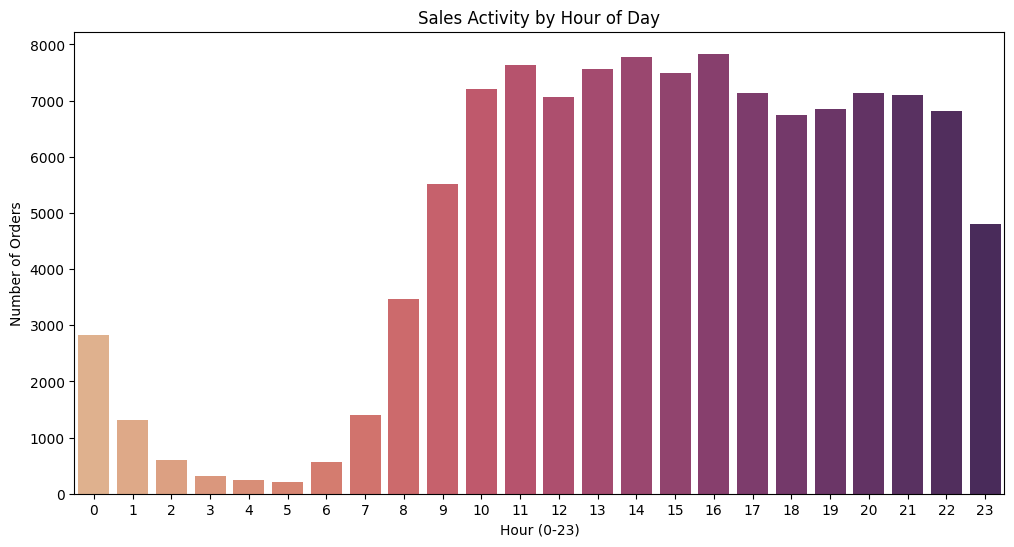

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()

print(f"💰 Total Revenue: {total_revenue:,.2f} BRL")
print(f"📦 Total Unique Orders: {total_orders}")

# Sales distribution by hour
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='purchase_hour', hue='purchase_hour', palette='flare', legend=False)
plt.title('Sales Activity by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Orders')
plt.show()

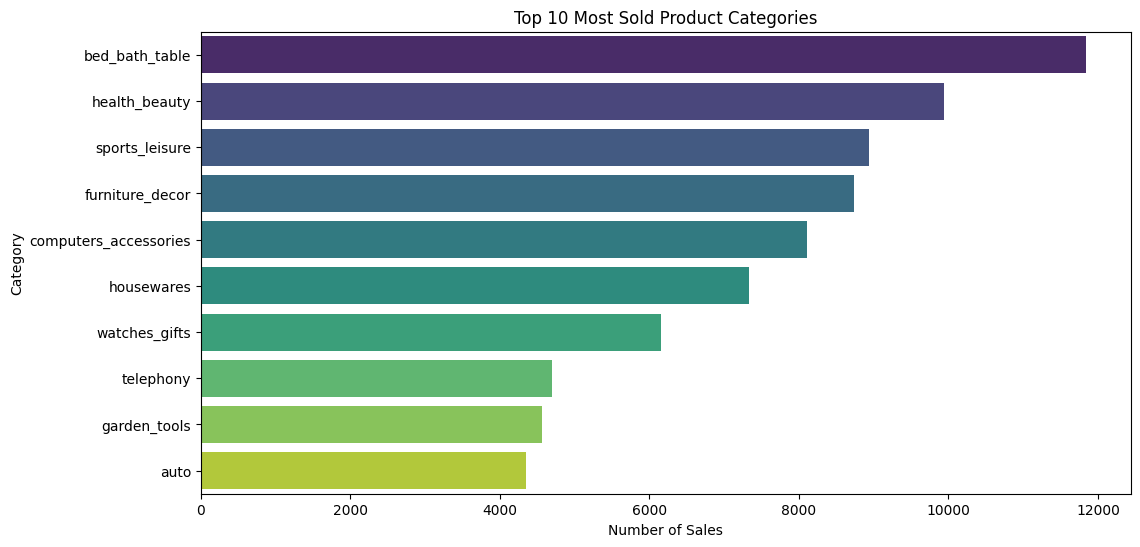

In [40]:
# Visualize Top 10 Product Categories (using English translations)
plt.figure(figsize=(12, 6))
top_cats = df['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, hue=top_cats.index, palette='viridis', legend=False)
plt.title('Top 10 Most Sold Product Categories')
plt.xlabel('Number of Sales')
plt.ylabel('Category')
plt.show()

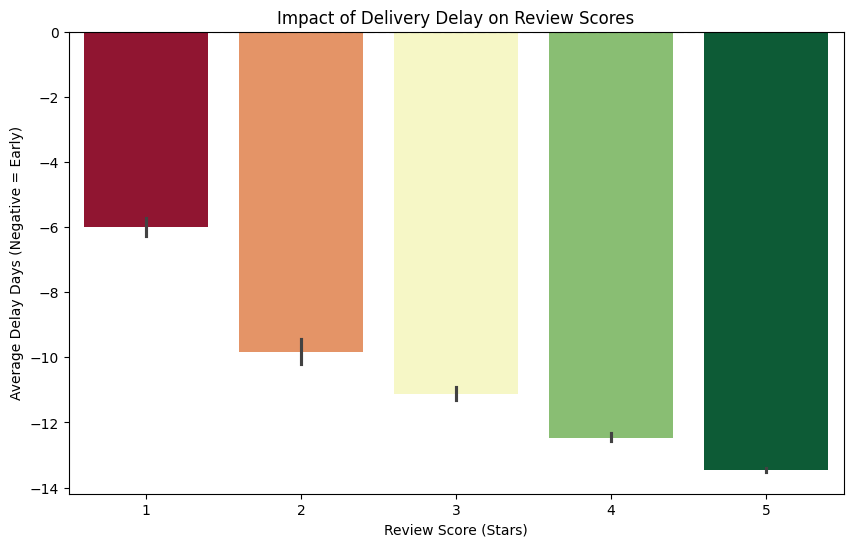

⭐ Global Average Rating: 4.03 / 5


In [41]:
# Calculate delivery delay (Actual delivery - Estimated delivery)
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# Correlation between Delay and Review Score
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='review_score', y='delivery_delay', hue='review_score', palette='RdYlGn', legend=False)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Impact of Delivery Delay on Review Scores')
plt.ylabel('Average Delay Days (Negative = Early)')
plt.xlabel('Review Score (Stars)')
plt.show()

print(f"⭐ Global Average Rating: {df['review_score'].mean():.2f} / 5")

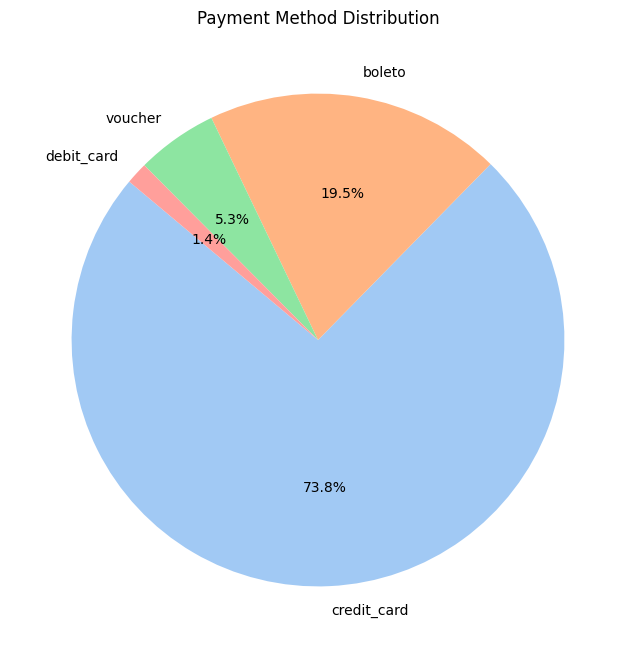


📍 Top 5 Cities by Orders:
customer_city
sao paulo         18267
rio de janeiro     8022
belo horizonte     3196
brasilia           2434
curitiba           1790
Name: count, dtype: int64

✅ Final Step: Cleaned dataset saved as 'olist_final_cleaned_data.csv'


In [42]:
# Payment Method Distribution
plt.figure(figsize=(8, 8))
payment_types = df['payment_type'].value_counts()
plt.pie(payment_types, labels=payment_types.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Distribution')
plt.show()

# Top 5 Cities by Order Count
print("\n📍 Top 5 Cities by Orders:")
print(df['customer_city'].value_counts().head(5))

# Exporting the cleaned master dataset
df.to_csv('olist_final_cleaned_data.csv', index=False)
print("\n✅ Final Step: Cleaned dataset saved as 'olist_final_cleaned_data.csv'")

👥 One-time Customers: 96.99%
🔄 Repeat Customers: 3.01%


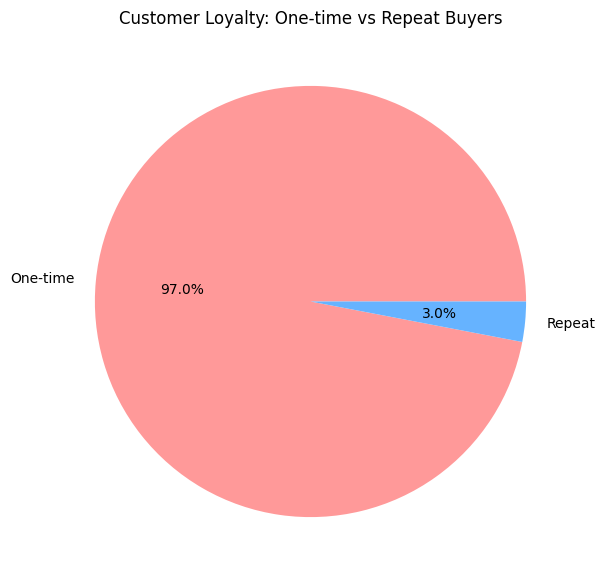

In [43]:
# Analysis 7: Customer Retention (One-time vs Repeat Customers)

# Counting orders per unique customer
customer_counts = df.groupby('customer_unique_id')['order_id'].nunique().value_counts()

# Calculate percentages
one_time_pct = (customer_counts[1] / customer_counts.sum()) * 100
repeat_pct = (customer_counts[customer_counts.index > 1].sum() / customer_counts.sum()) * 100

print(f"👥 One-time Customers: {one_time_pct:.2f}%")
print(f"🔄 Repeat Customers: {repeat_pct:.2f}%")

# Visualization
plt.figure(figsize=(7, 7))
plt.pie([one_time_pct, repeat_pct], labels=['One-time', 'Repeat'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Customer Loyalty: One-time vs Repeat Buyers')
plt.show()

/tmp/ipykernel_9583/1398118965.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_shipping.index, y=state_shipping.values, palette='coolwarm')


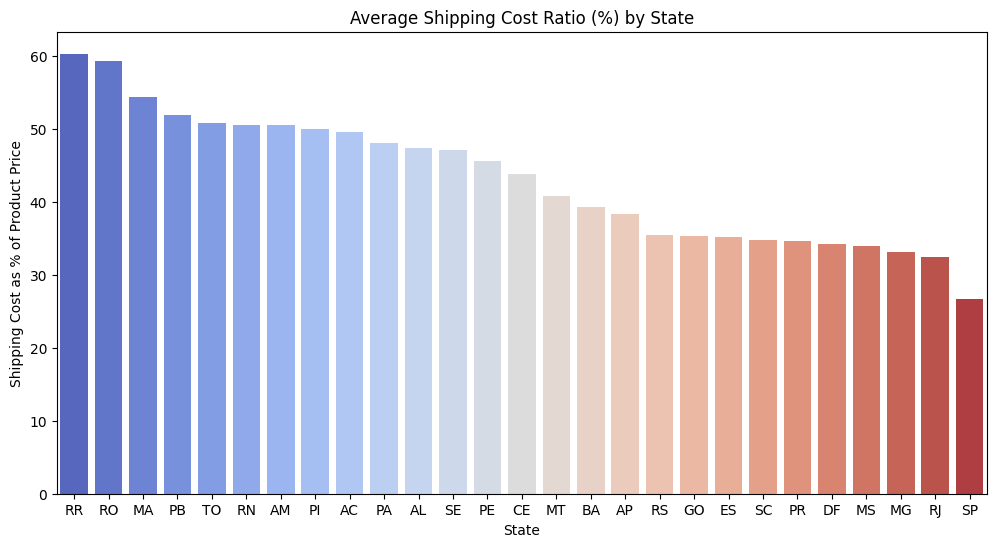

In [44]:
# Analysis 8: Freight Value vs Product Price

# Calculate the ratio of shipping cost to product price
df['shipping_ratio'] = (df['freight_value'] / df['price']) * 100

# Average shipping ratio per state
state_shipping = df.groupby('customer_state')['shipping_ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_shipping.index, y=state_shipping.values, palette='coolwarm')
plt.title('Average Shipping Cost Ratio (%) by State')
plt.ylabel('Shipping Cost as % of Product Price')
plt.xlabel('State')
plt.show()

# Insight: States far from the center (like AC, AM, RR) will have higher shipping costs.

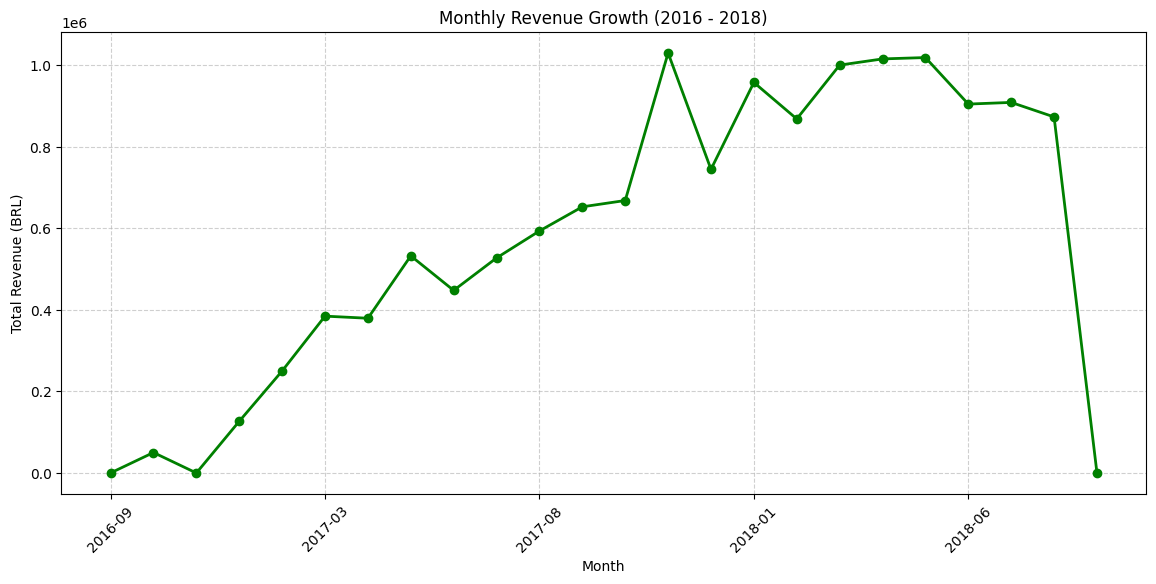

In [45]:
# Analysis 9: Monthly Sales Trend (Growth Analysis)

# 1. Create a Year-Month column
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 2. Group by month and calculate revenue
monthly_sales = df.groupby('month_year')['price'].sum()

# 3. Plotting the growth
plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Revenue Growth (2016 - 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()